In [1]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt


# important imports 
import sys
sys.path.insert(0, "../")  
from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_PROCESSES_REGRESSION import GP_REGRESSION as GP 
from TOOL_BOX_OF_FUNCTIONS.METROPOLIS_1_CHAIN import METROPOLIS_1_CHAIN as MH
from TOOL_BOX_OF_FUNCTIONS.BAYESIAN_REGRESSION import BAYES_REG as BR 
from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_CRED_INTERVALS import GAUS_CRED_INTER as GCI 
from TOOL_BOX_OF_FUNCTIONS.FORMATED_PRINTING import FORMATED_PRINTING as FP 
from TOOL_BOX_OF_FUNCTIONS.METROPOLIS_1_CHAIN import METROPOLIS_1_CHAIN as MH
from TOOL_BOX_OF_FUNCTIONS.Lecture8 import exercise8 as e8
from TOOL_BOX_OF_FUNCTIONS.LECTURE_9 import exercise9 as e9

import numpy as np
import jax.numpy as jnp


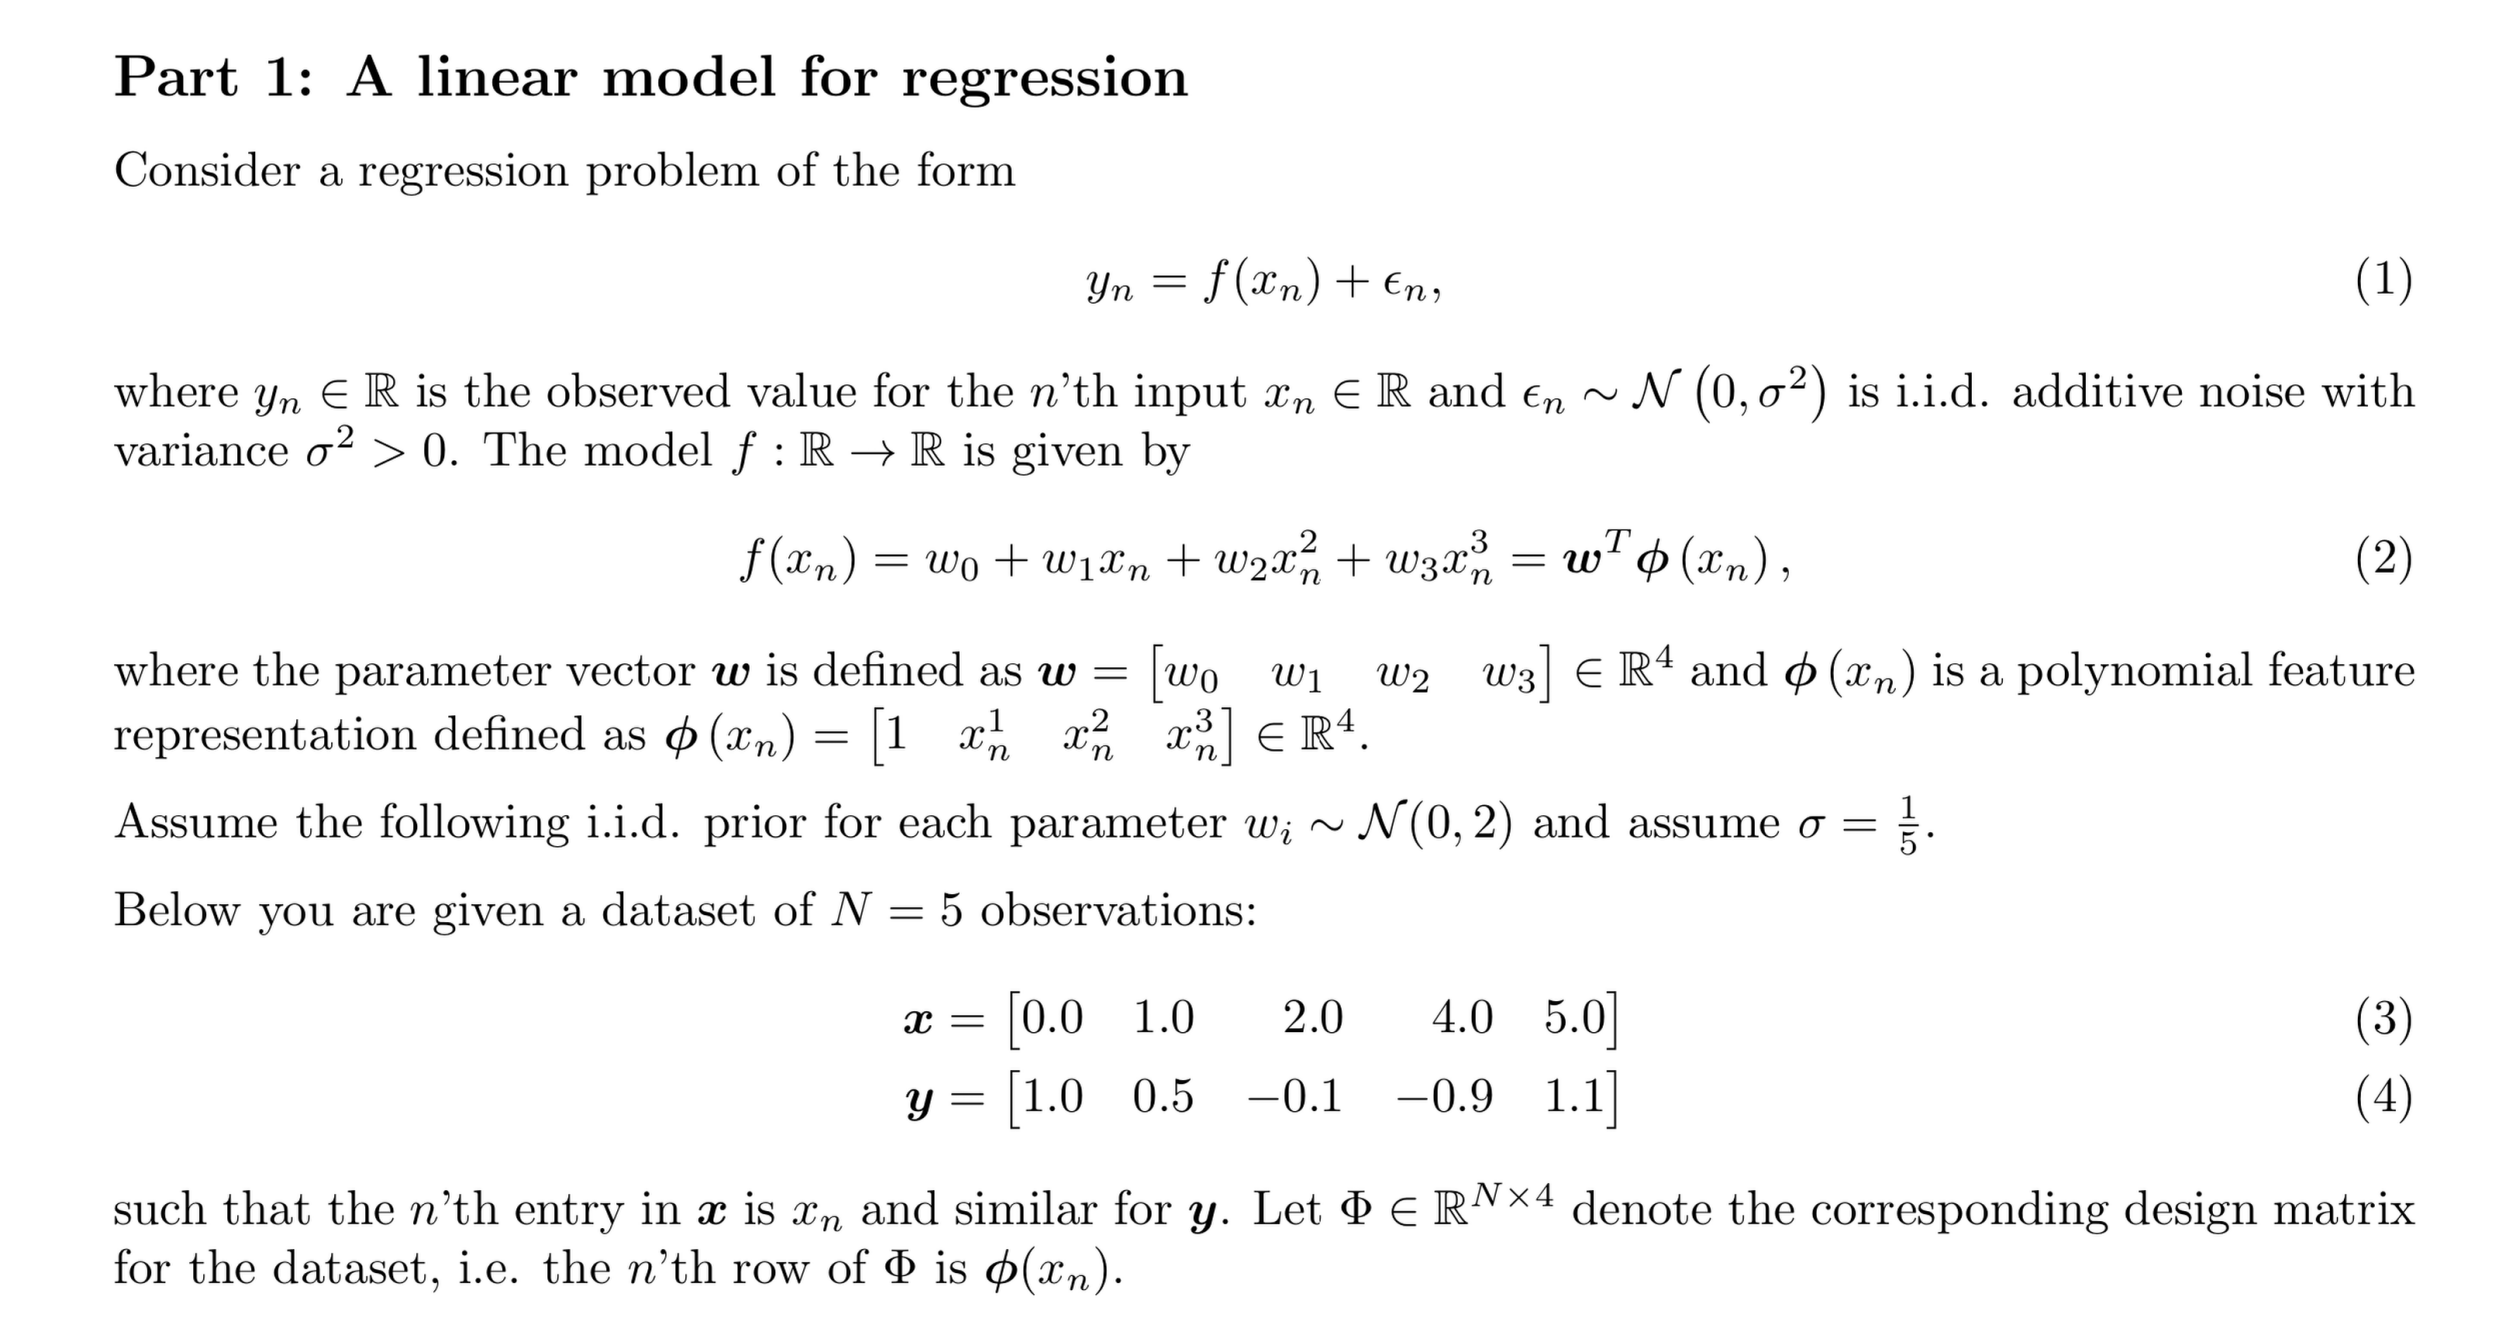

In [7]:
x = jnp.array([0.0, 1.0, 2.0, 4.0, 5.0])
y = jnp.array([1.0, 0.5, -0.1, -0.9, 1.1]).reshape(-1, 1)

In [8]:
def design_matrix(x):
    return jnp.column_stack((jnp.ones(len(x)), x, x**2, x**3))

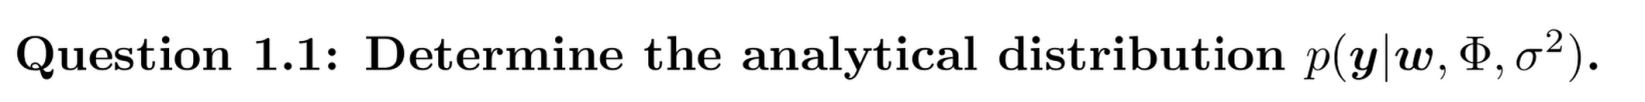

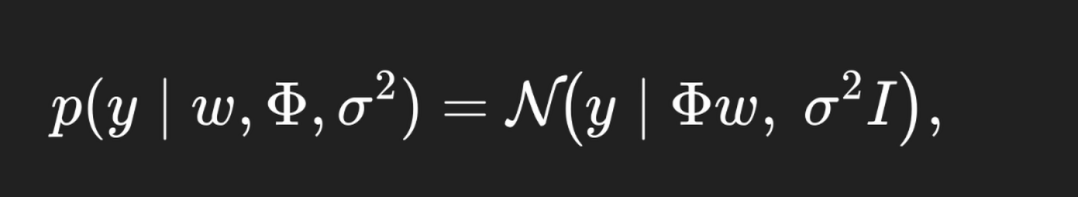

In [9]:
p_likelihood = design_matrix(x)

print(p_likelihood)

[[  1.   0.   0.   0.]
 [  1.   1.   1.   1.]
 [  1.   2.   4.   8.]
 [  1.   4.  16.  64.]
 [  1.   5.  25. 125.]]


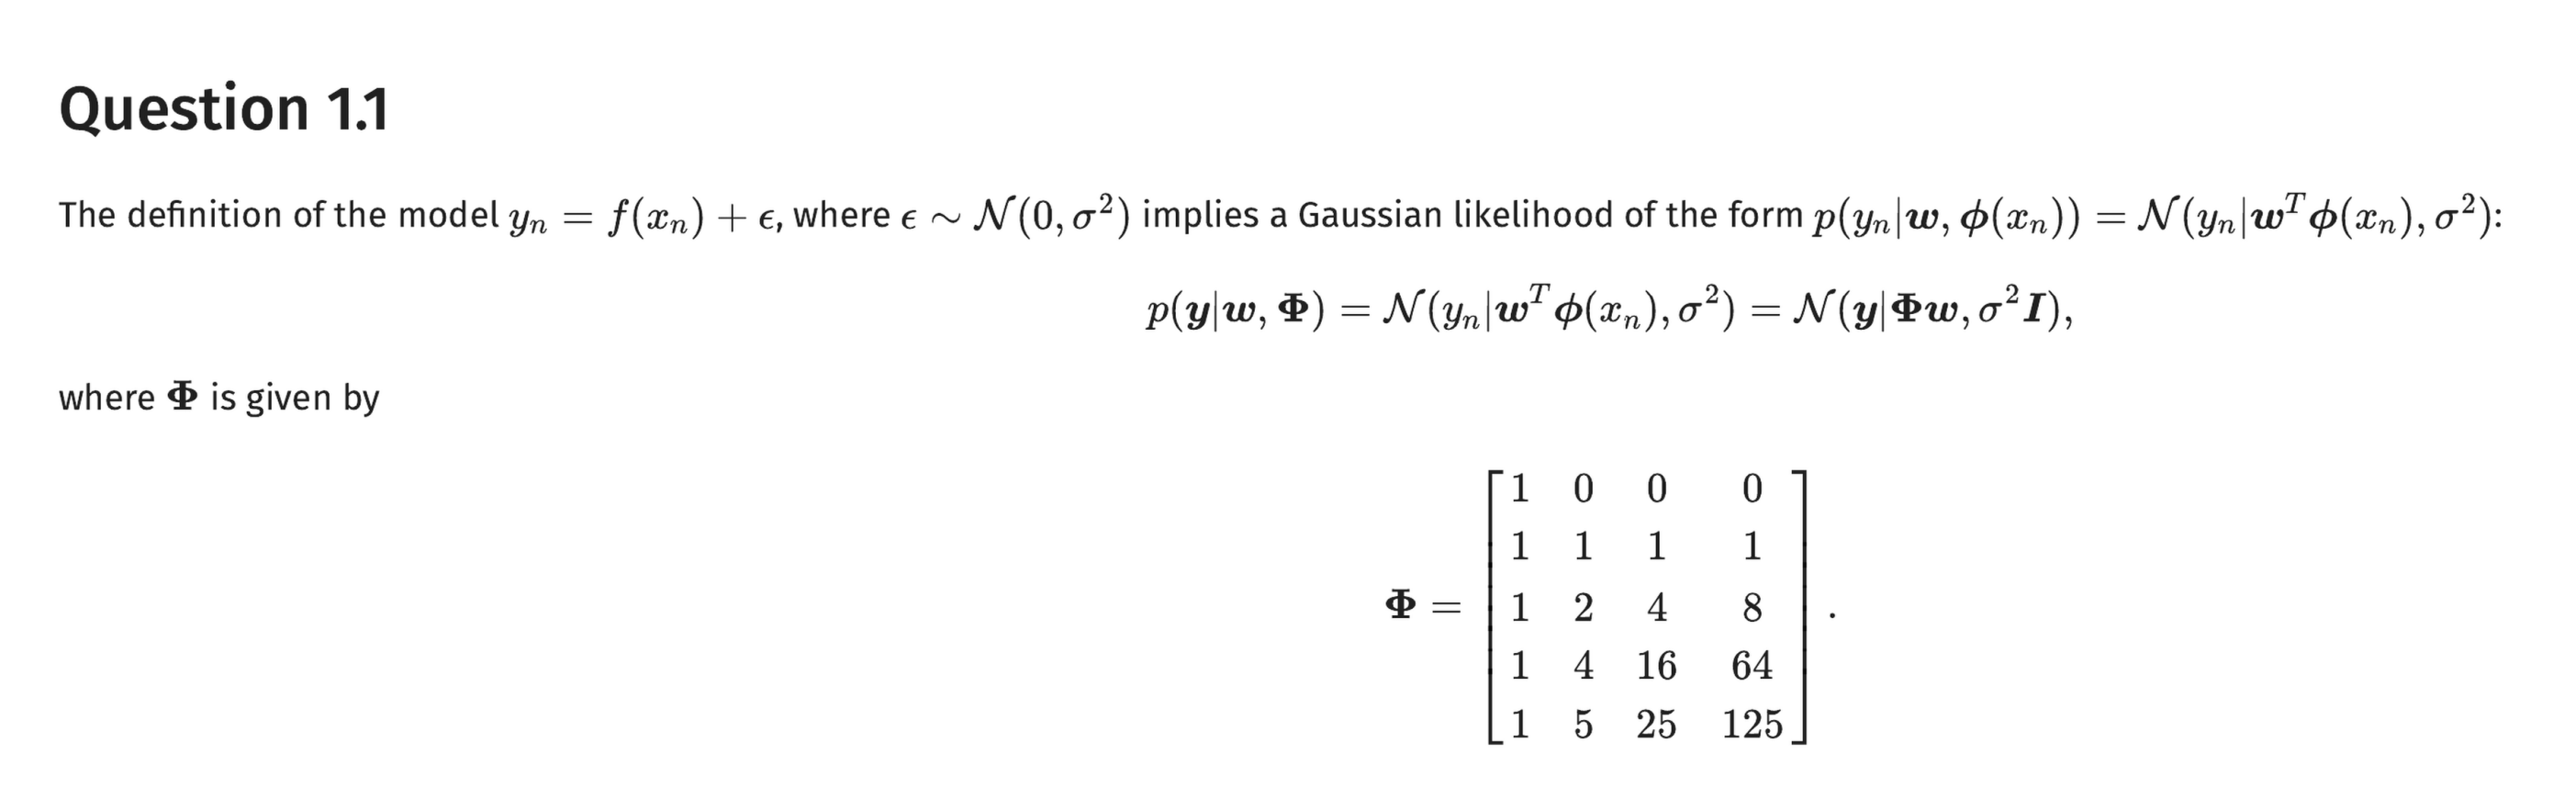

In [47]:
model = BR.BayesianLinearRegression(Phi=p_likelihood, y=y, alpha=1/2, beta=25)

In [48]:
w_mle = model.get_w_mle()

print(f"W_mle: \n{w_mle}")

W_mle: 
[[ 0.95336134]
 [ 0.26645658]
 [-0.69327731]
 [ 0.12892157]]


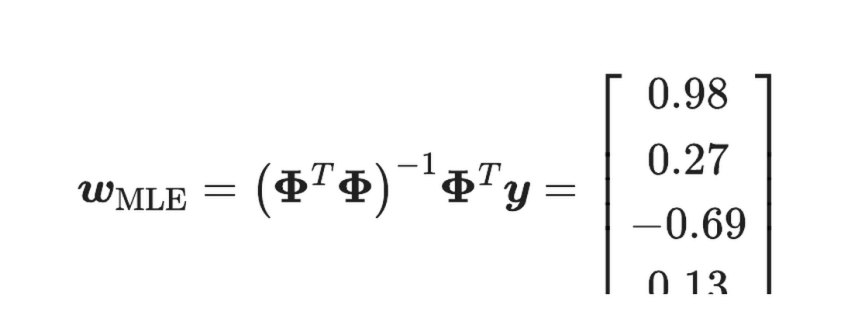

In [49]:



mu_p, S_p = model.compute_posterior(alpha=1/2, beta=25)

print(mu_p)

print(S_p)

[[ 0.9470195 ]
 [ 0.2469239 ]
 [-0.67903942]
 [ 0.12686206]]
[[ 0.03658534 -0.04402131  0.0148169  -0.0014999 ]
 [-0.04402131  0.13294307 -0.06430176  0.00799773]
 [ 0.0148169  -0.06430176  0.03584205 -0.00480552]
 [-0.0014999   0.00799773 -0.00480552  0.00066975]]


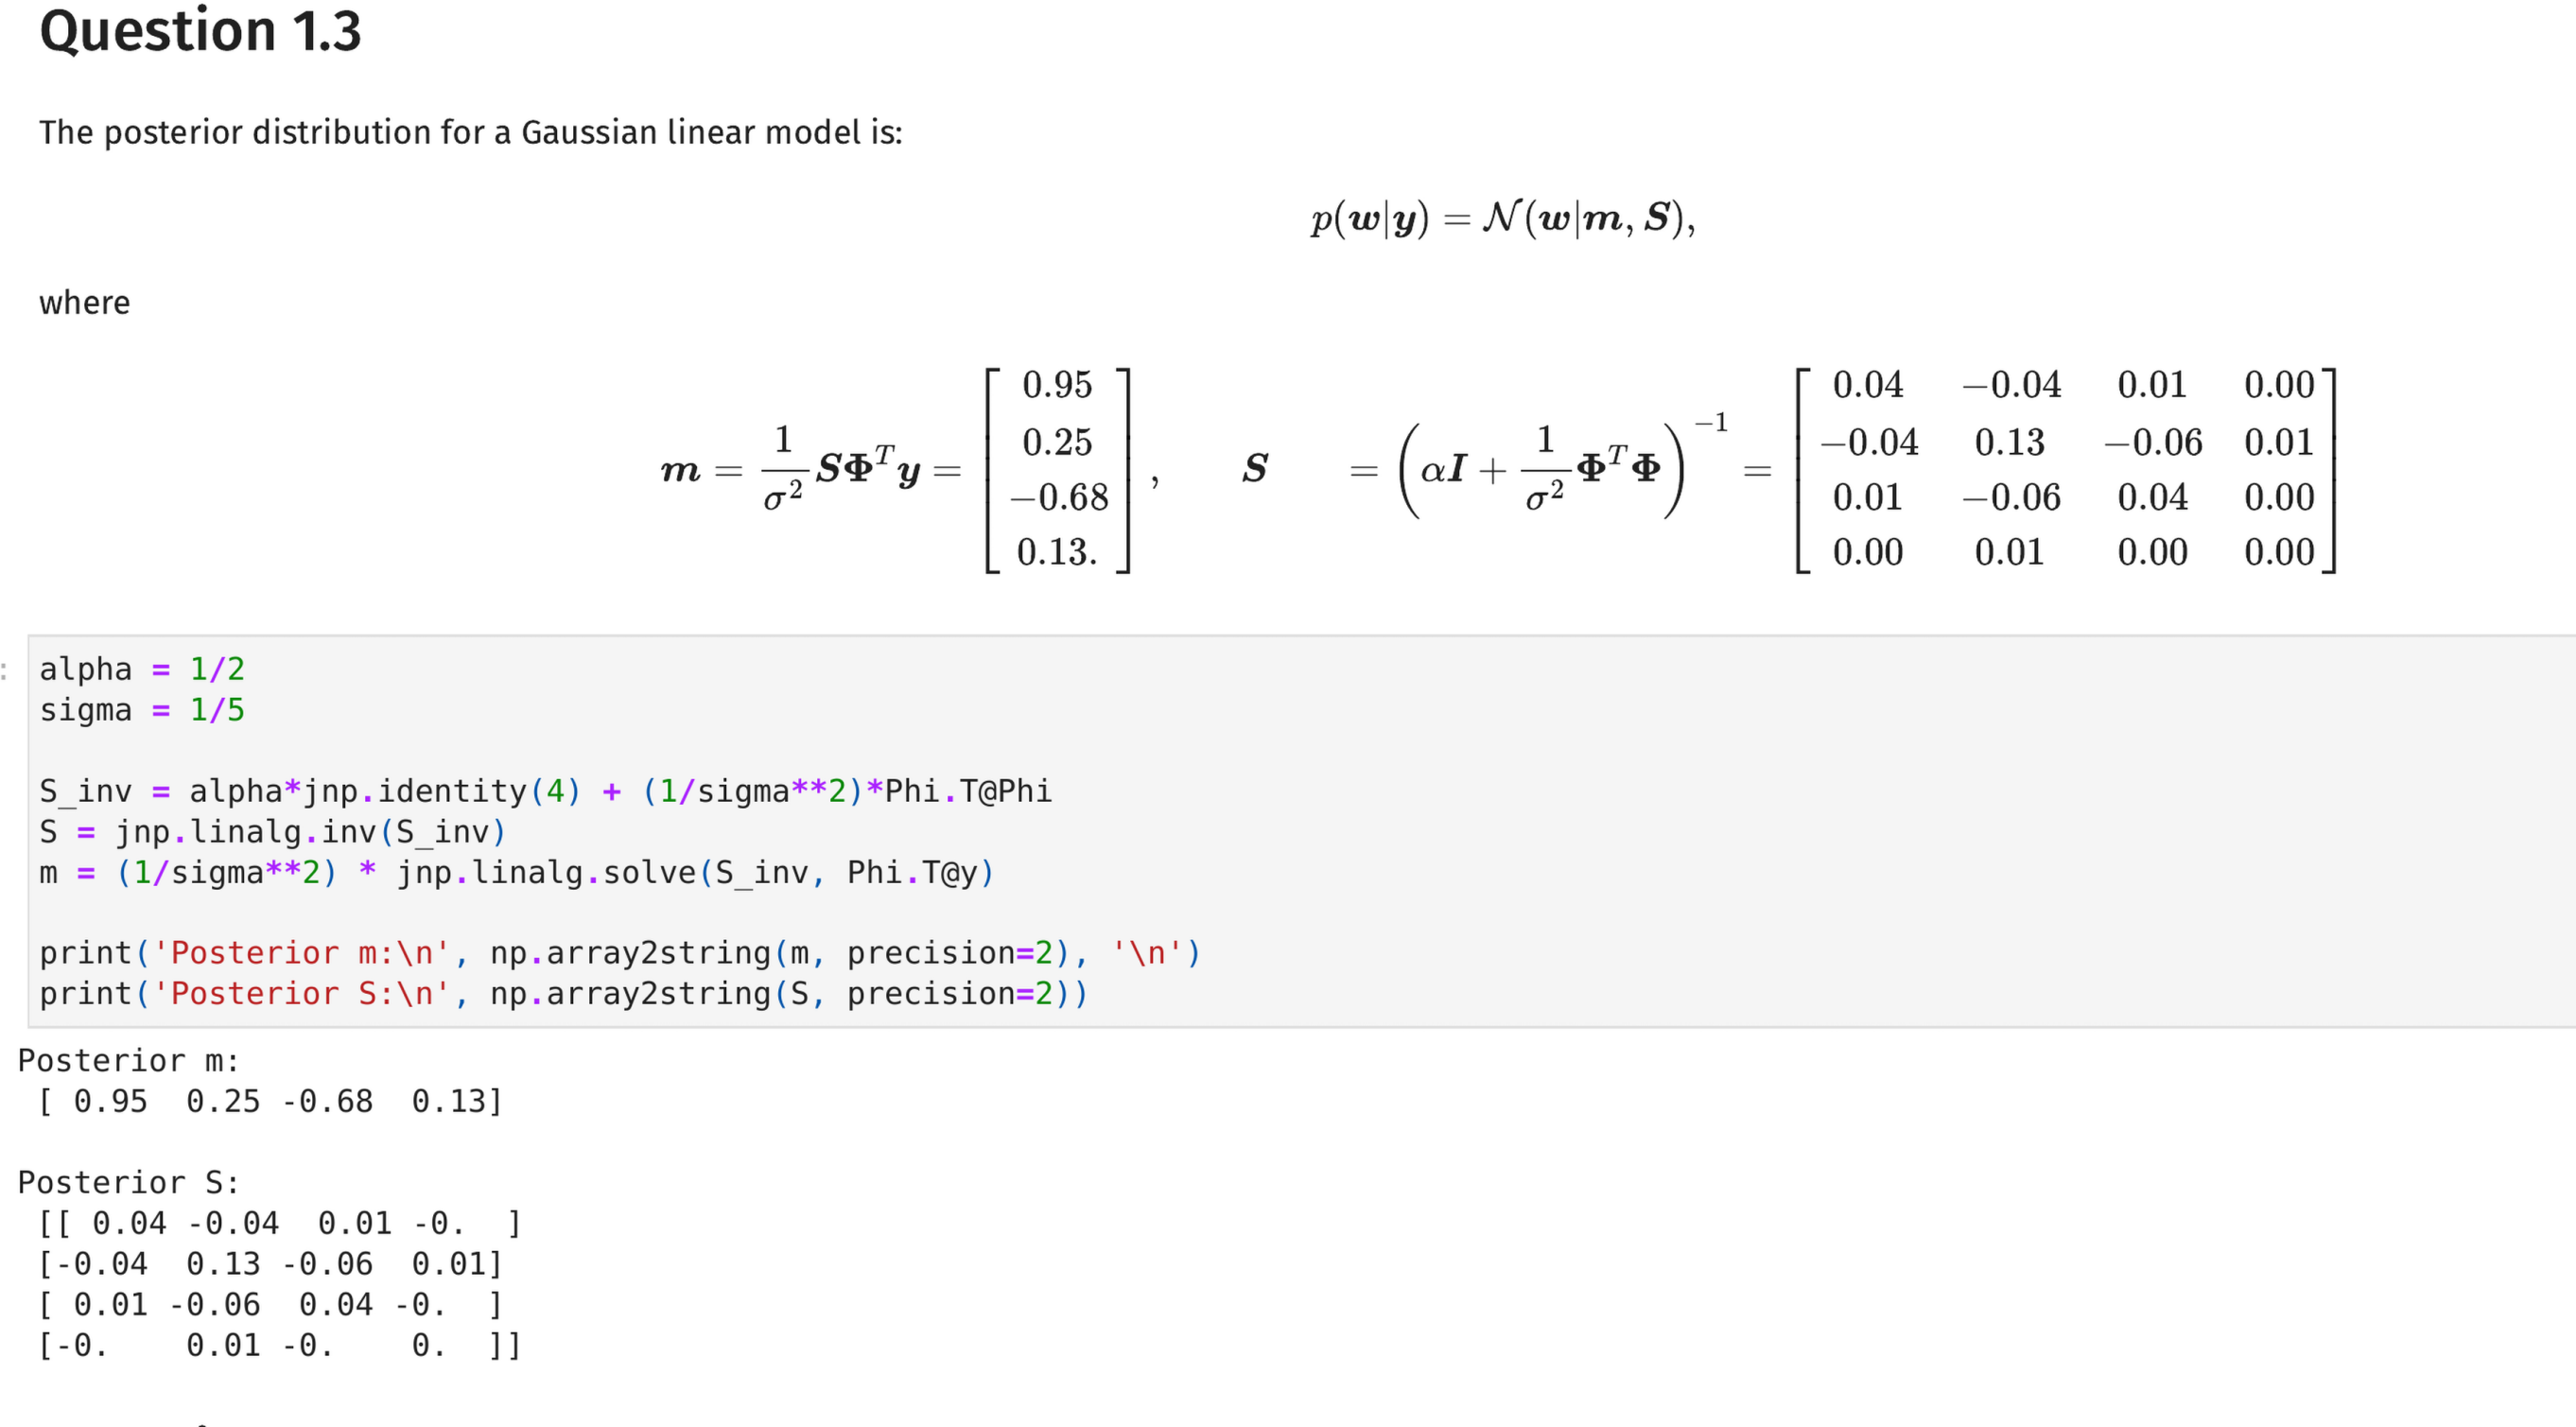

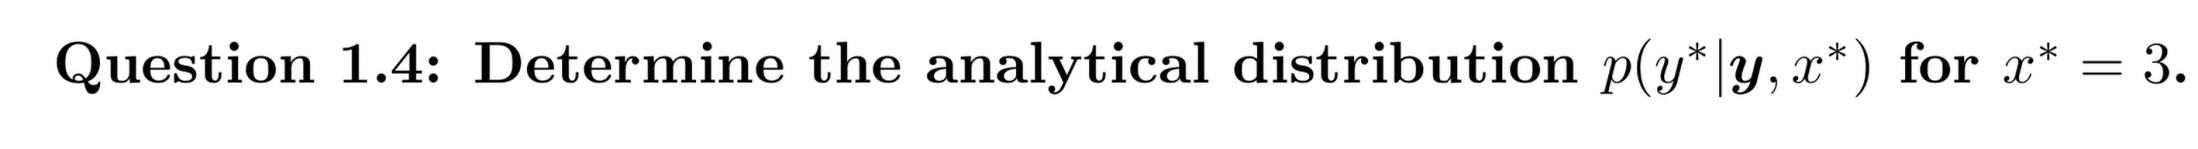

In [50]:
x_star = jnp.array([3])

mu_y, S_y = model.predict_y(design_matrix(x_star))

print(mu_y)

[-0.99828786]


In [51]:
print(S_y)

[0.07396223]


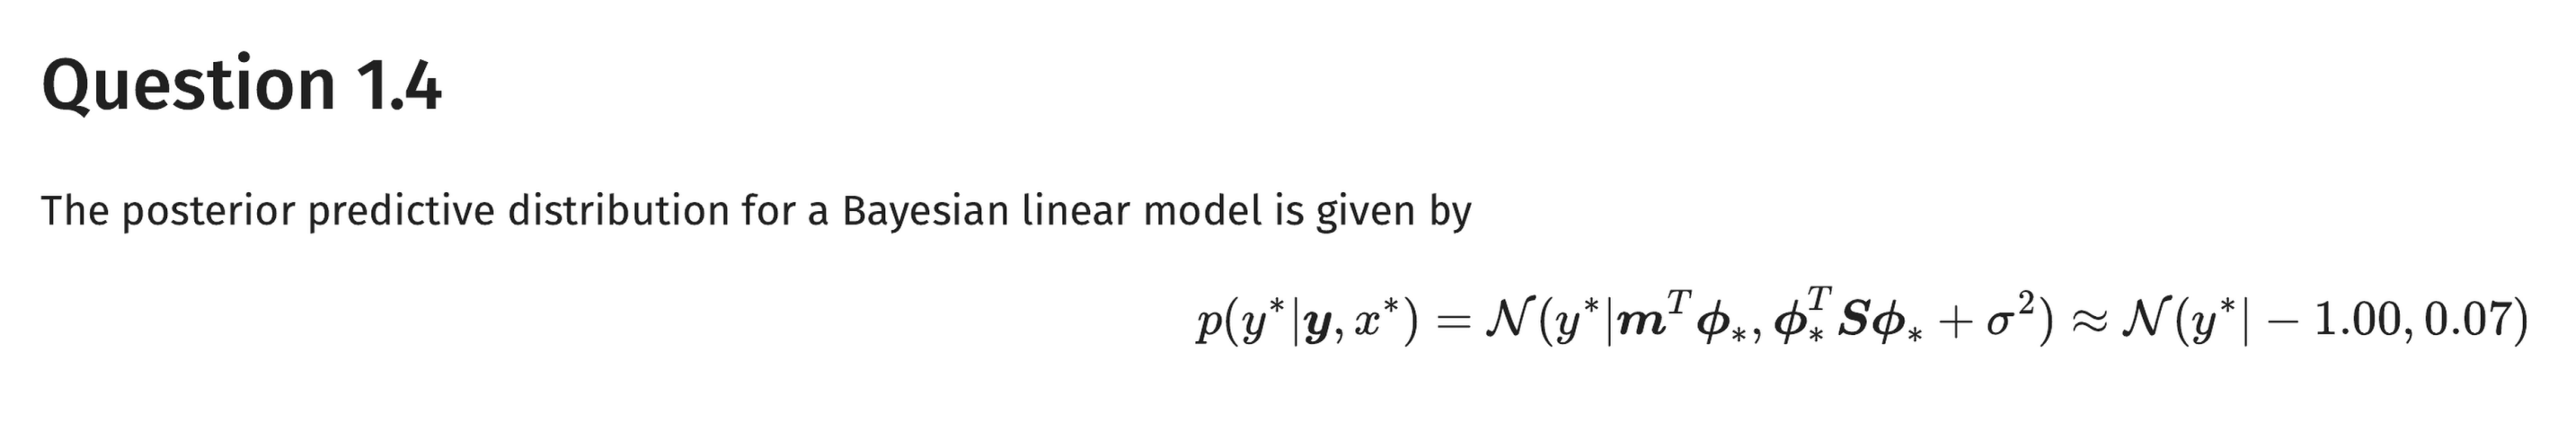

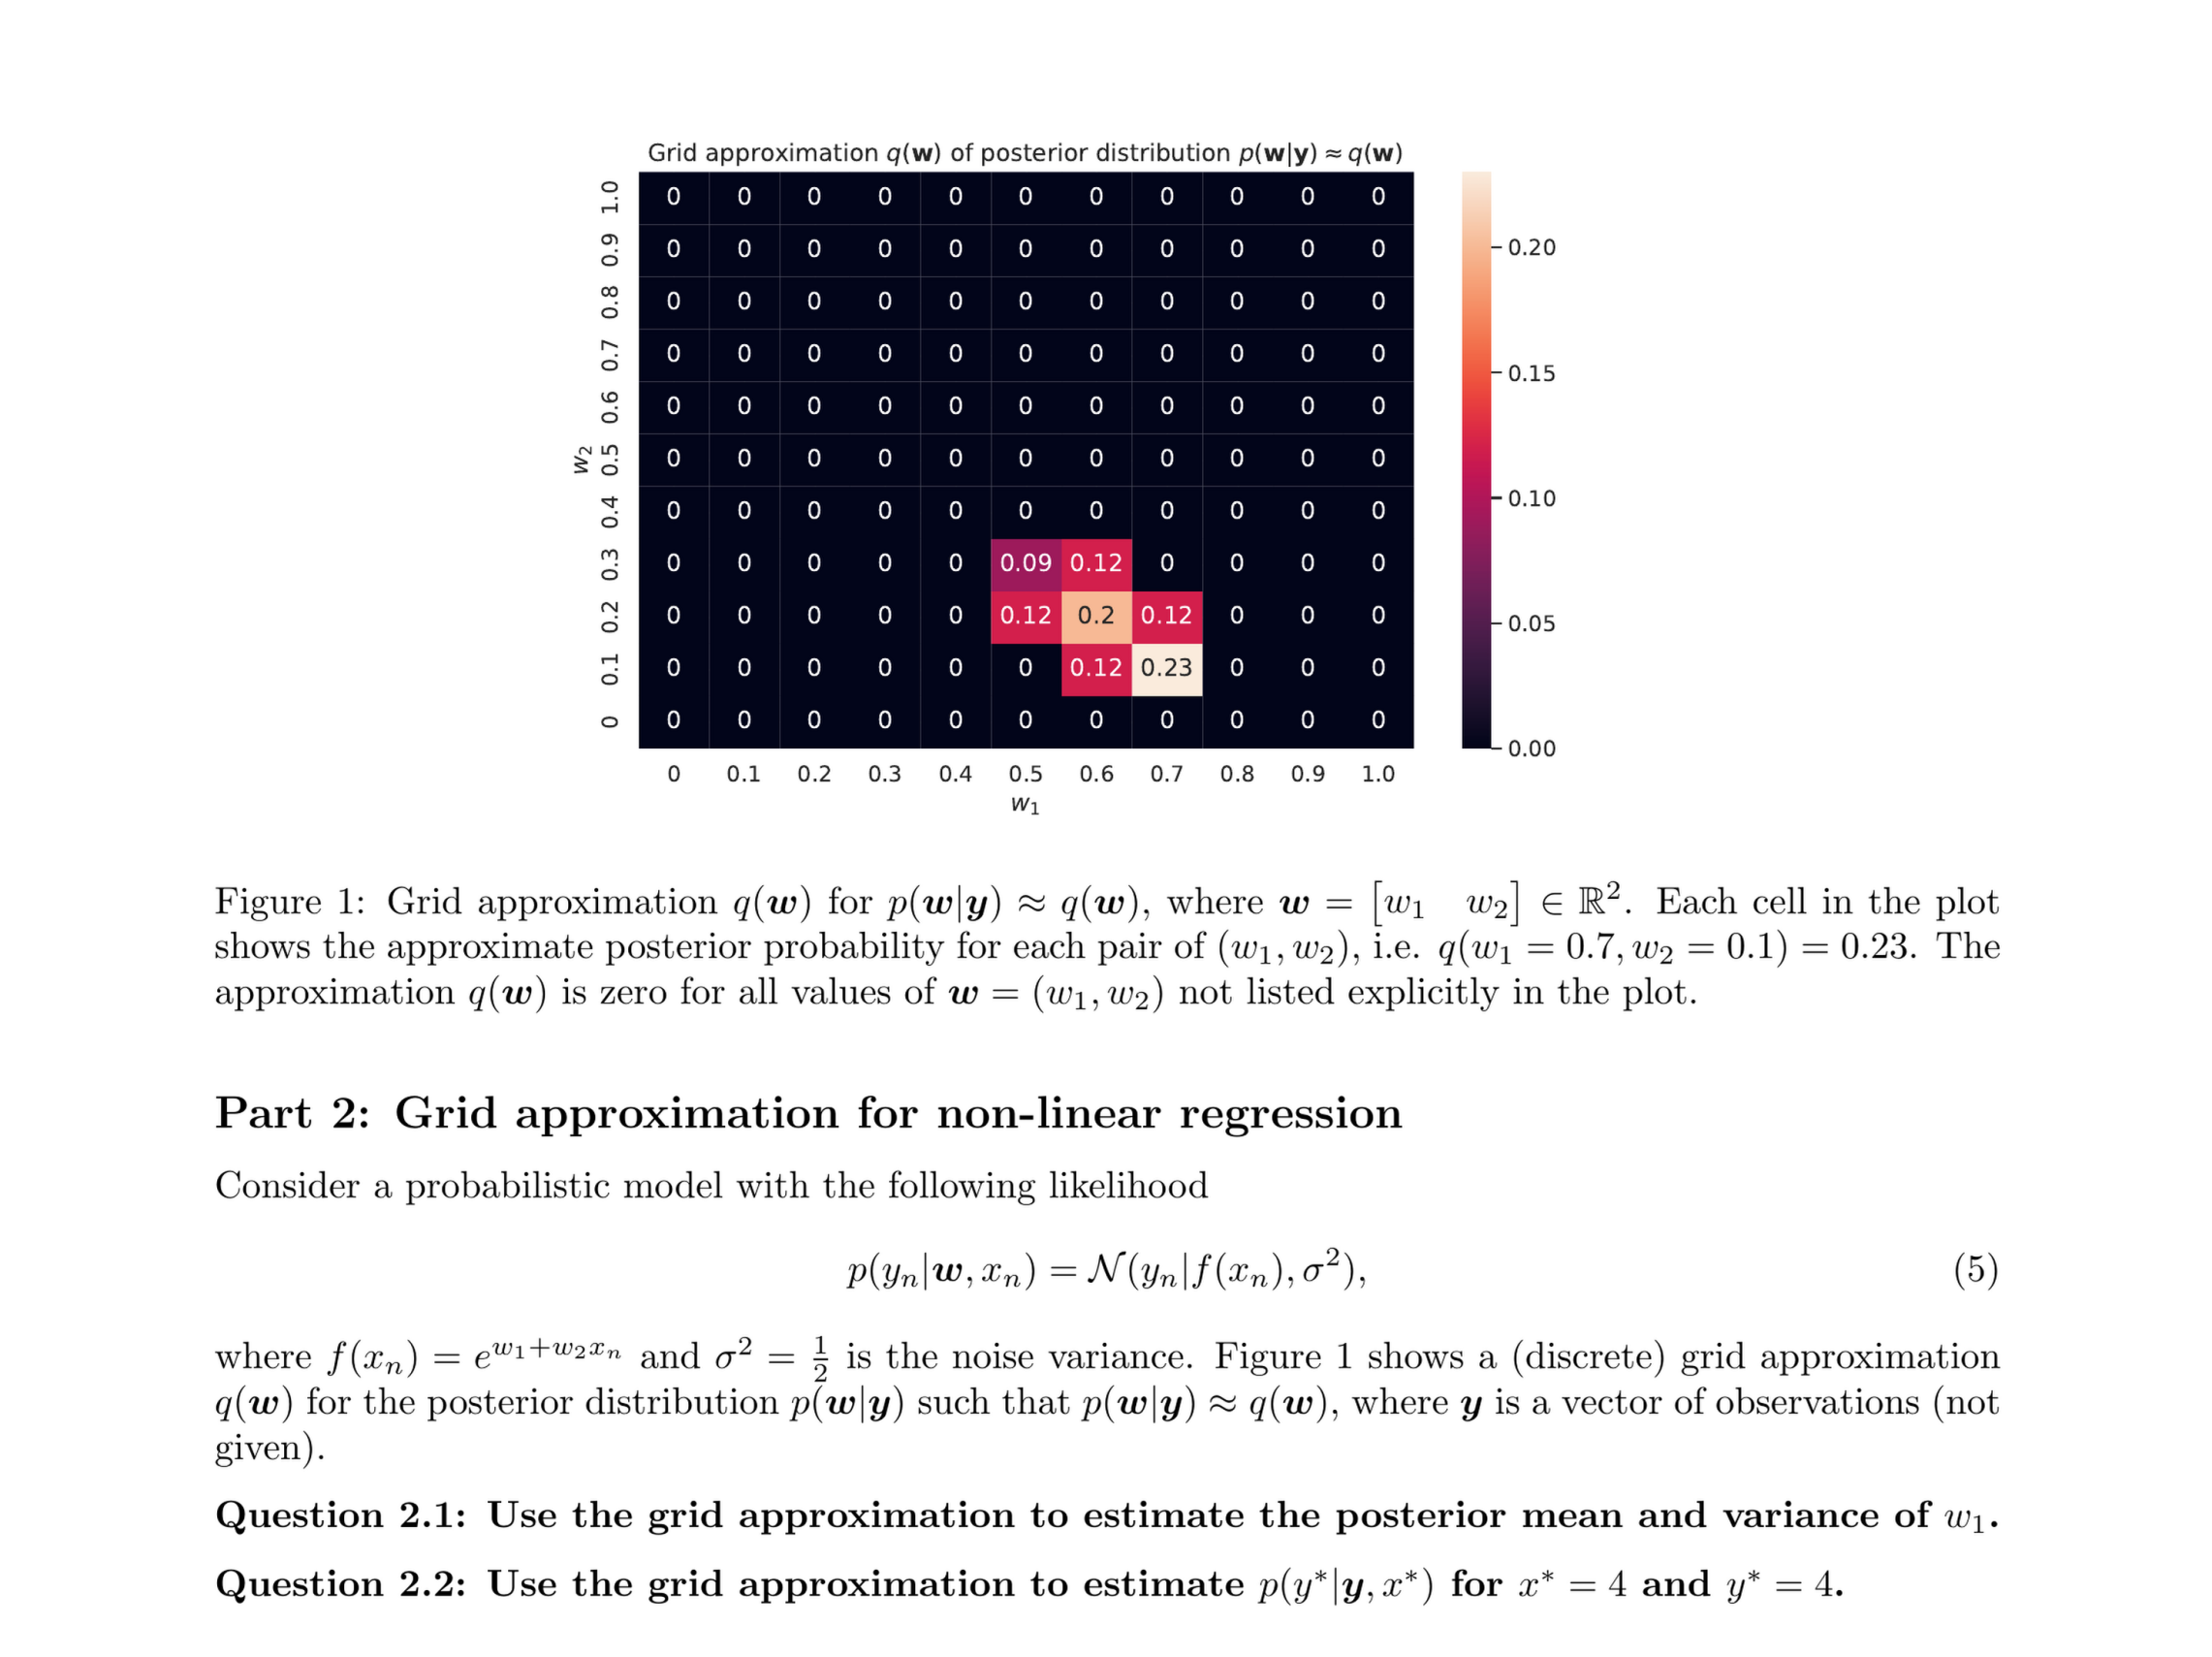

In [142]:
weights = [0.5, 0.6, 0.7]
sub_expressions = [(0.09, 0.12), (0.12, 0.2, 0.12), (0.12, 0.23)]

# Calculate the result using list comprehension
result = sum(weight * sum(sub) for weight, sub in zip(weights, sub_expressions))
print(result)



0.614


In [143]:
weights_2 = jnp.array([0.5, 0.5, 0.6, 0.6, 0.6, 0.7, 0.7])

post = jnp.array([0.09, 0.12, 0.12, 0.2, 0.12, 0.12, 0.23])

In [144]:
# Use existing JAX arrays to avoid list-float operations
variance = jnp.sum((weights_2 - result) ** 2 * post)

print(variance)

0.005403999999999997


In [263]:
log_npdf = lambda x, m, v: -0.5 * jnp.log(2*jnp.pi*v) - (x - m)**2 / (2 * v)

import numpy as np

# Variance form: v = variance
npdf      = lambda x, m, v: np.exp(-((x - m)**2) / (2.0 * v)) / np.sqrt(2.0 * np.pi * v)
nlogpdf   = lambda x, m, v: -0.5*np.log(2.0*np.pi*v) - ((x - m)**2)/(2.0*v)

# Std-dev form: s = standard deviation
npdf_std  = lambda x, m, s: np.exp(-0.5 * ((x - m)/s)**2) / (s * np.sqrt(2.0*np.pi))


In [264]:
mean = lambda w : jnp.exp(w[0] + w[1] * 4)

weights_tuple = jnp.array([(0.5, 0.2), (0.5, 0.3), (0.6, 0.1), (0.6, 0.2), (0.6, 0.3), (0.7, 0.1), (0.7, 0.2)])

In [265]:
# Compute posterior-weighted PDF terms with clearer names
x_eval = 4
variance = 0.5

weighted_pdf_terms = []
for idx in range(weights_tuple.shape[0]):
    pdf_val = npdf(x_eval, mean(weights_tuple[idx]), variance)
    weighted_term = pdf_val * post[idx]
    weighted_pdf_terms.append(weighted_term)

# Keep compatibility with cell 25 which uses `ddds`
ddds = weighted_pdf_terms
print(sum(ddds))

0.3078398853863474


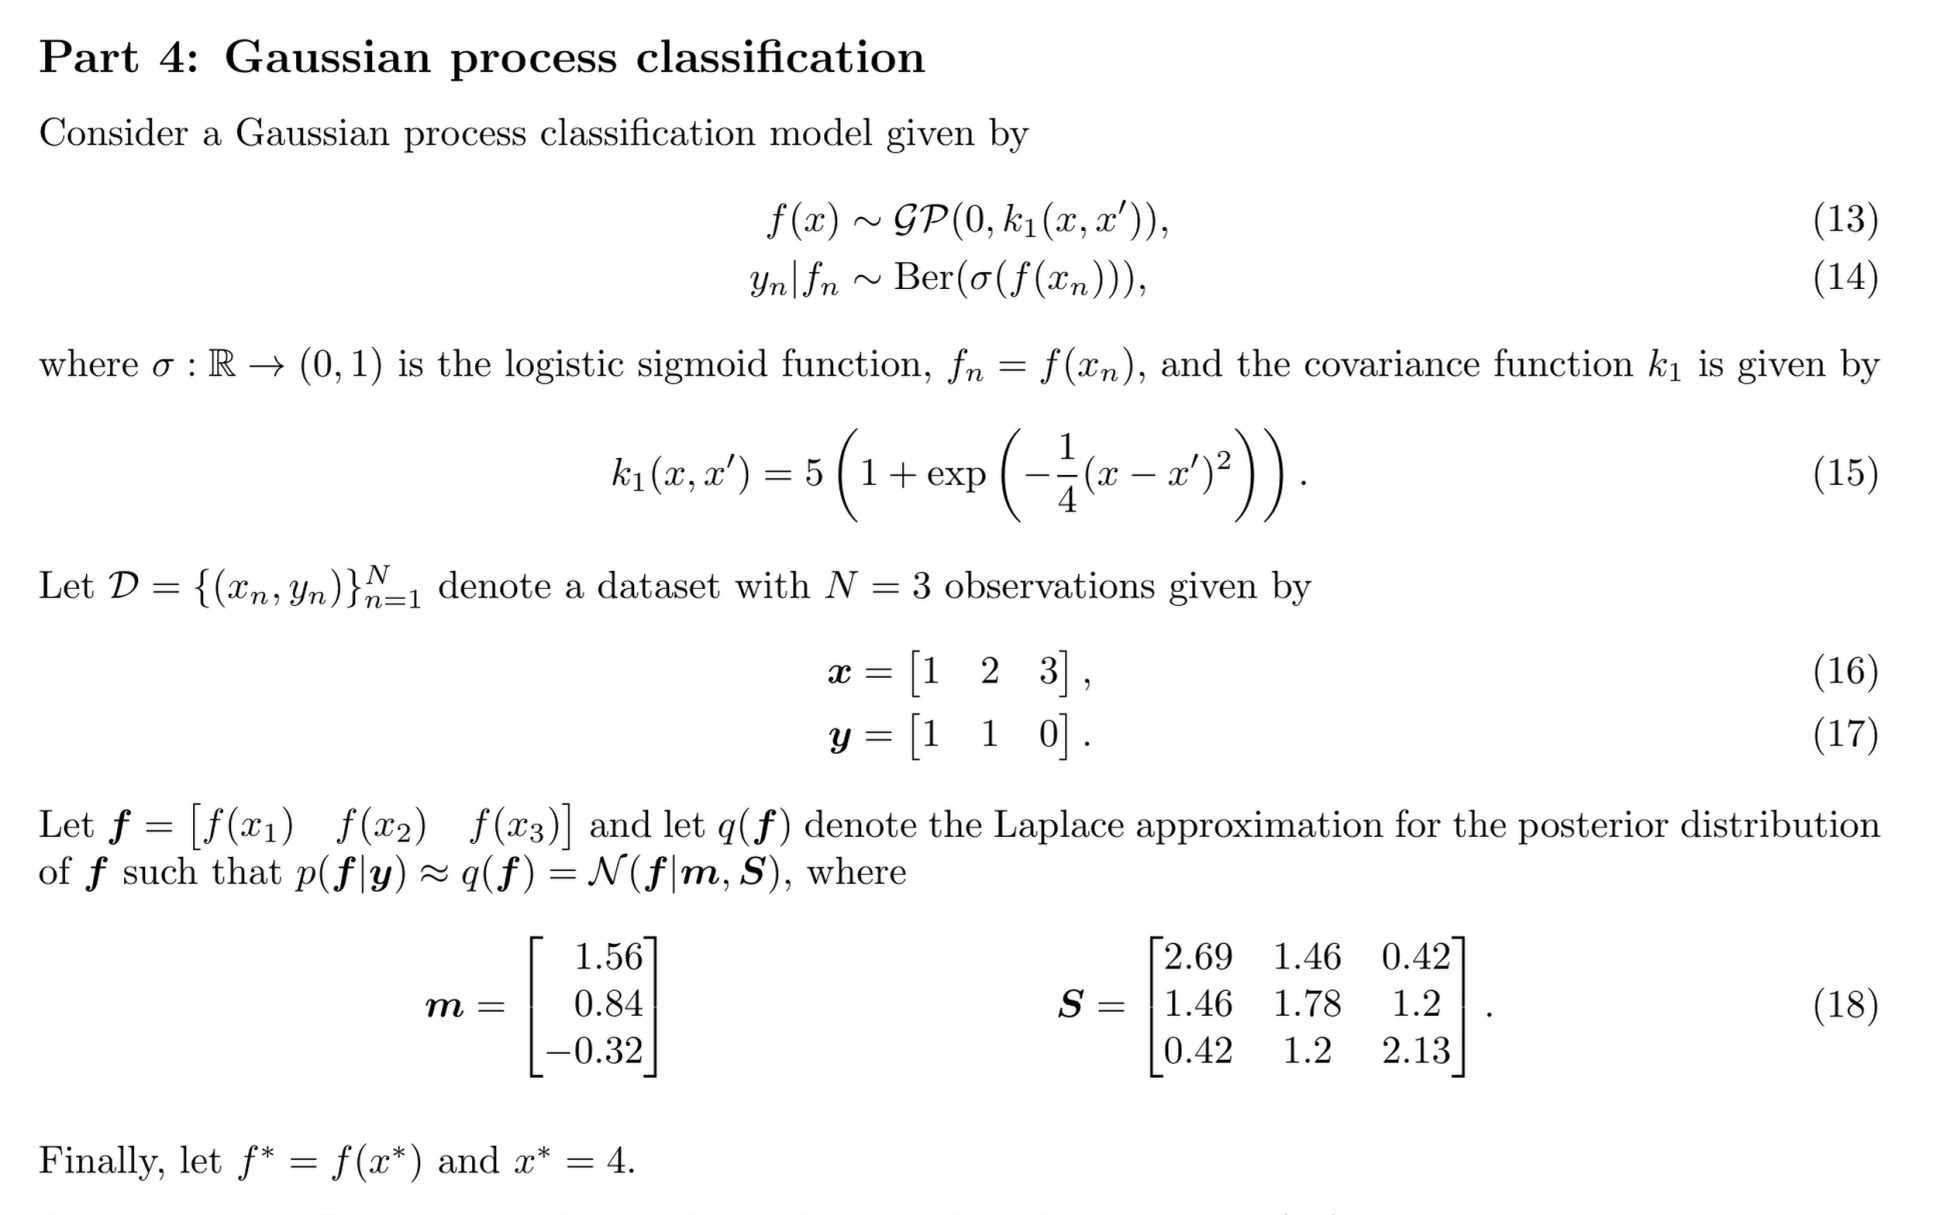

In [288]:
from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_PROCESS_CLASSIFICATION import GAUSSIAN_PROCESS_CLASSIFICATION as GPC 

In [307]:
x = jnp.array([1, 2, 3]).reshape(-1, 1)
y = jnp.array([1, 1, 0]).reshape(-1, 1)


def squared_exponential_new(tau, kappa, lengthscale):
    return 5 * (1 + jnp.exp(-1/4*(tau**2)))

kernel = GPC.StationaryIsotropicKernel(squared_exponential_new)
likelihood = GPC.BernoulliLikelihood
model = GPC.GaussianProcessClassification(x, y, likelihood, kernel, kappa=1., lengthscale=1.)

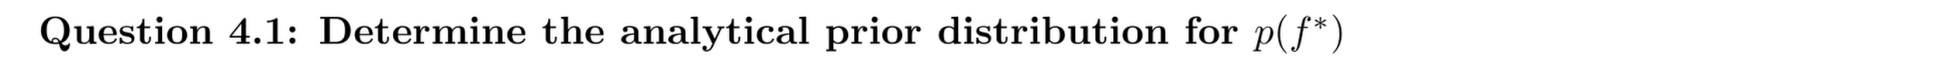

In [309]:
prior_m, prior_S = model.prior_predict_f(jnp.array([0]))

print(prior_m)
print(prior_S)

[0.]
[[10.00000001]]


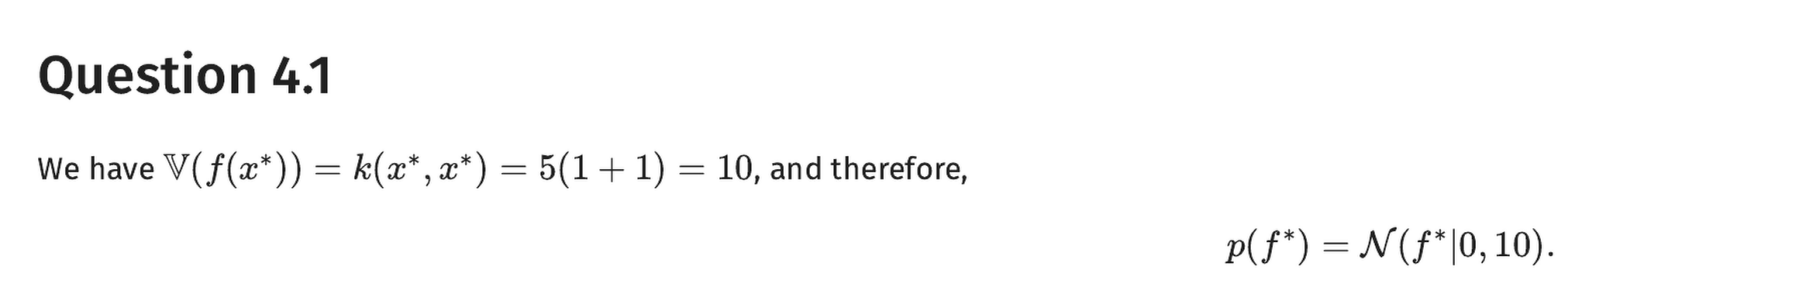

In [312]:
prior_S_y = model.prior_predict_y(jnp.array([0]))
print(prior_S_y)

[0.5]


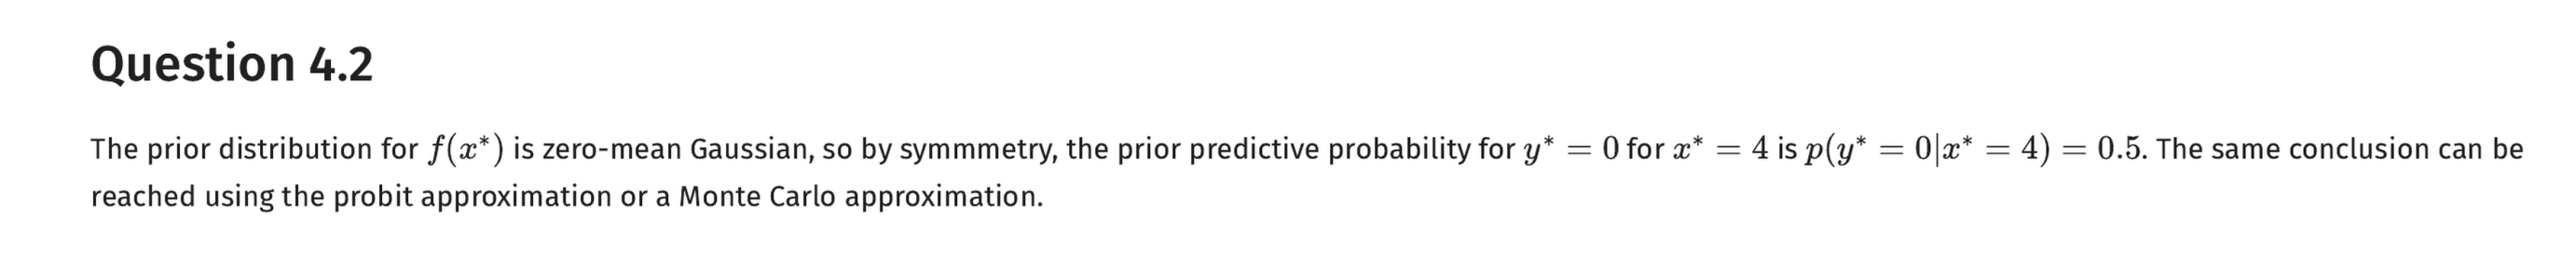

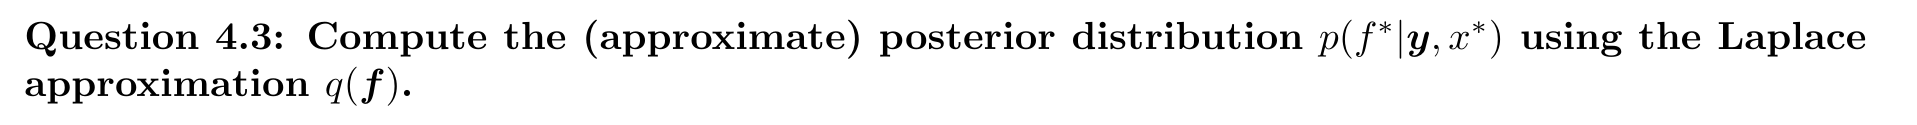

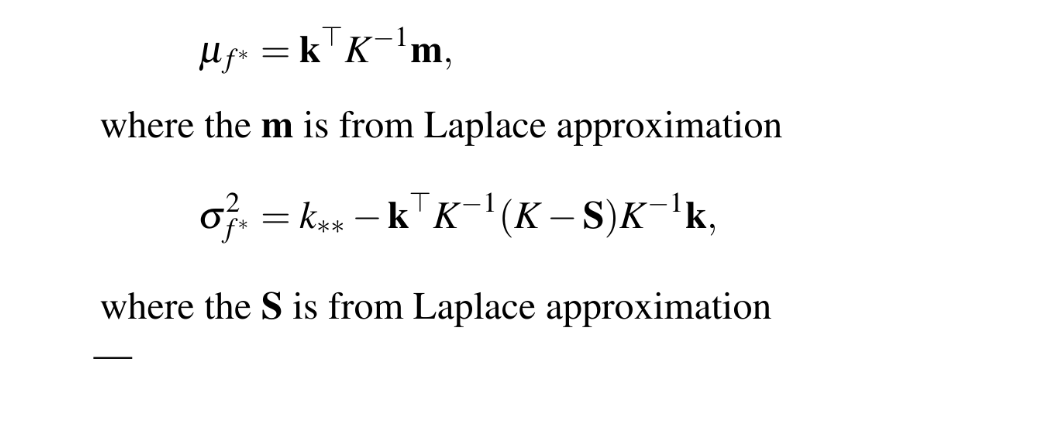


In [336]:
x_star = jnp.array([4])
K = kernel.contruct_kernel(X1=x, X2=x)
k = kernel.contruct_kernel(X1=x_star, X2=x)
m = jnp.array([1.56, 0.84, -0.32]).reshape(-1, 1)
k_ss = kernel.contruct_kernel(X1=x_star, X2=x_star)

K_inv = jnp.linalg.inv(K)

mu = k @ K_inv @ m
print(mu)

S = jnp.array([
    [2.69, 1.46, 0.42],
    [1.46, 1.78, 1.2],
    [0.42,1.2 ,2.13 ]
])

first = k @ K_inv
first_t = first.T


sigma_f = k_ss - first @ (K - S) @ first_t

print(sigma_f)

[[-0.7082184]]
[[4.16431586]]


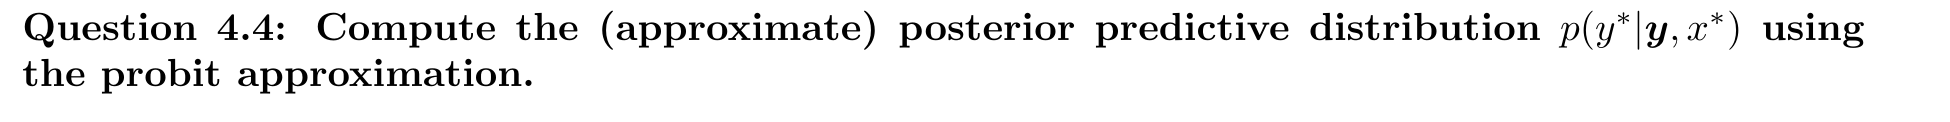


In [338]:
p = GPC.probit(mu / (jnp.sqrt( 8 / jnp.pi  + jnp.diag(sigma_f))))
print(p)

[[0.3922773]]


In [358]:
def squared_exponential_new(tau, kappa, lengthscale):
    return 1/10 *(5 * (1 + jnp.exp(-1/4*(tau**2))))

kernel_2 = GPC.StationaryIsotropicKernel(squared_exponential_new)

likelihood = GPC.BernoulliLikelihood
model_2 = GPC.GaussianProcessClassification(x, y, likelihood, kernel_2, kappa=1., lengthscale=1.)



In [356]:
K_prime = kernel_2.contruct_kernel(X1=x, X2=x)

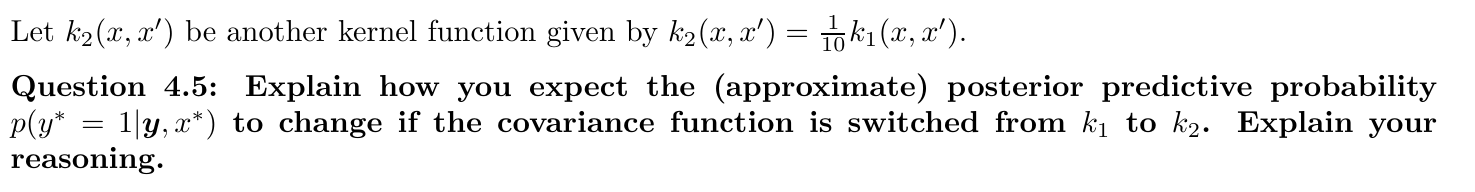

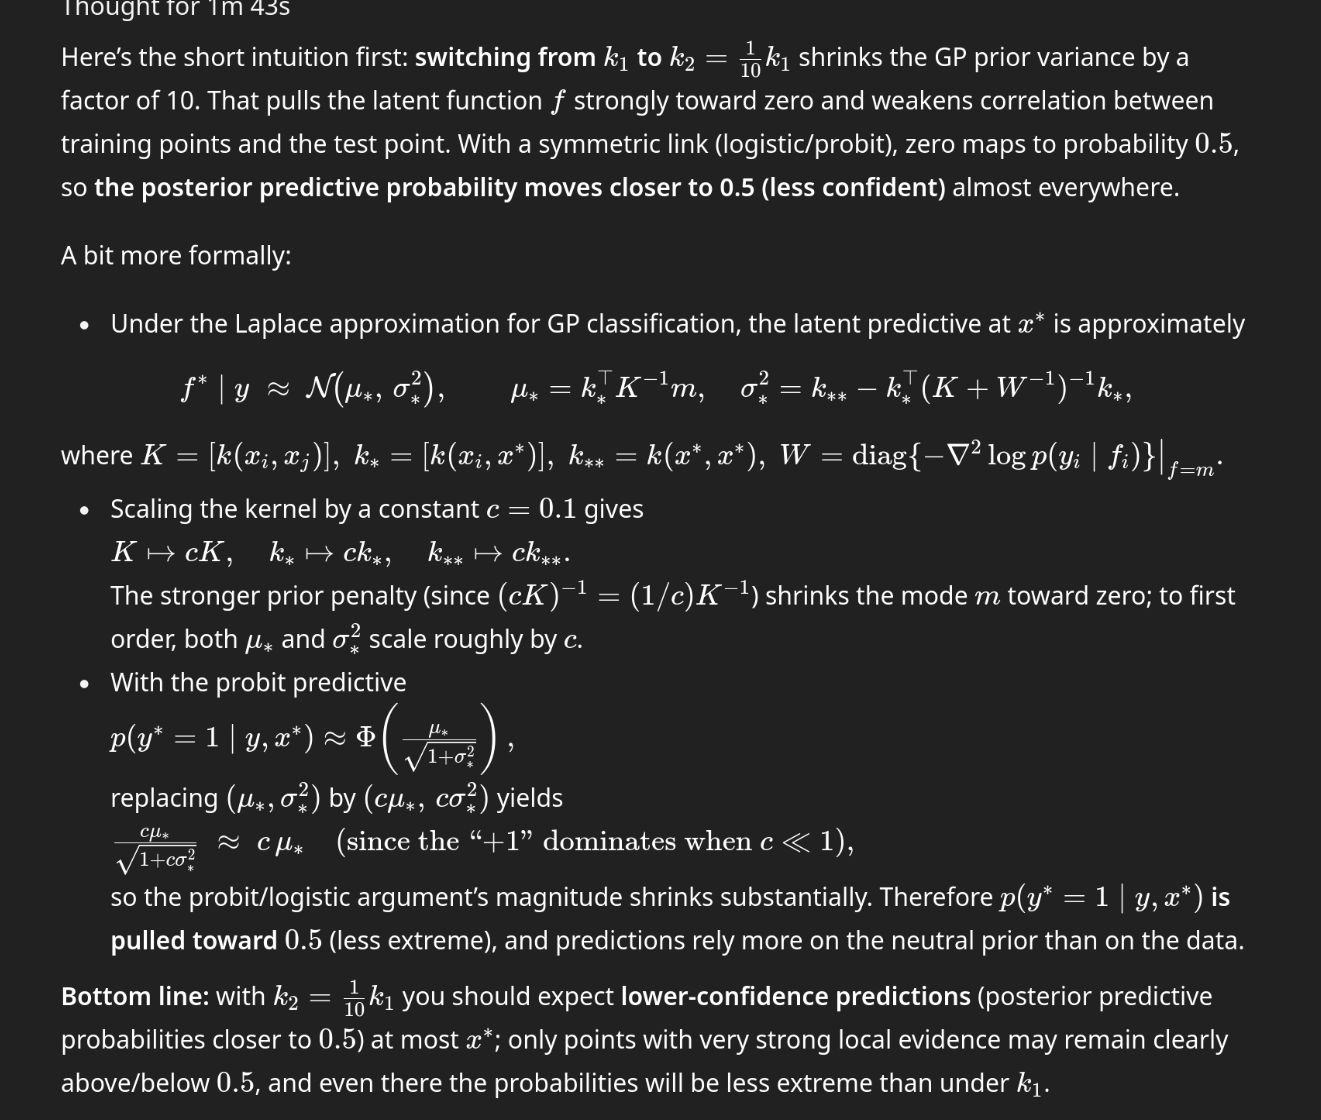

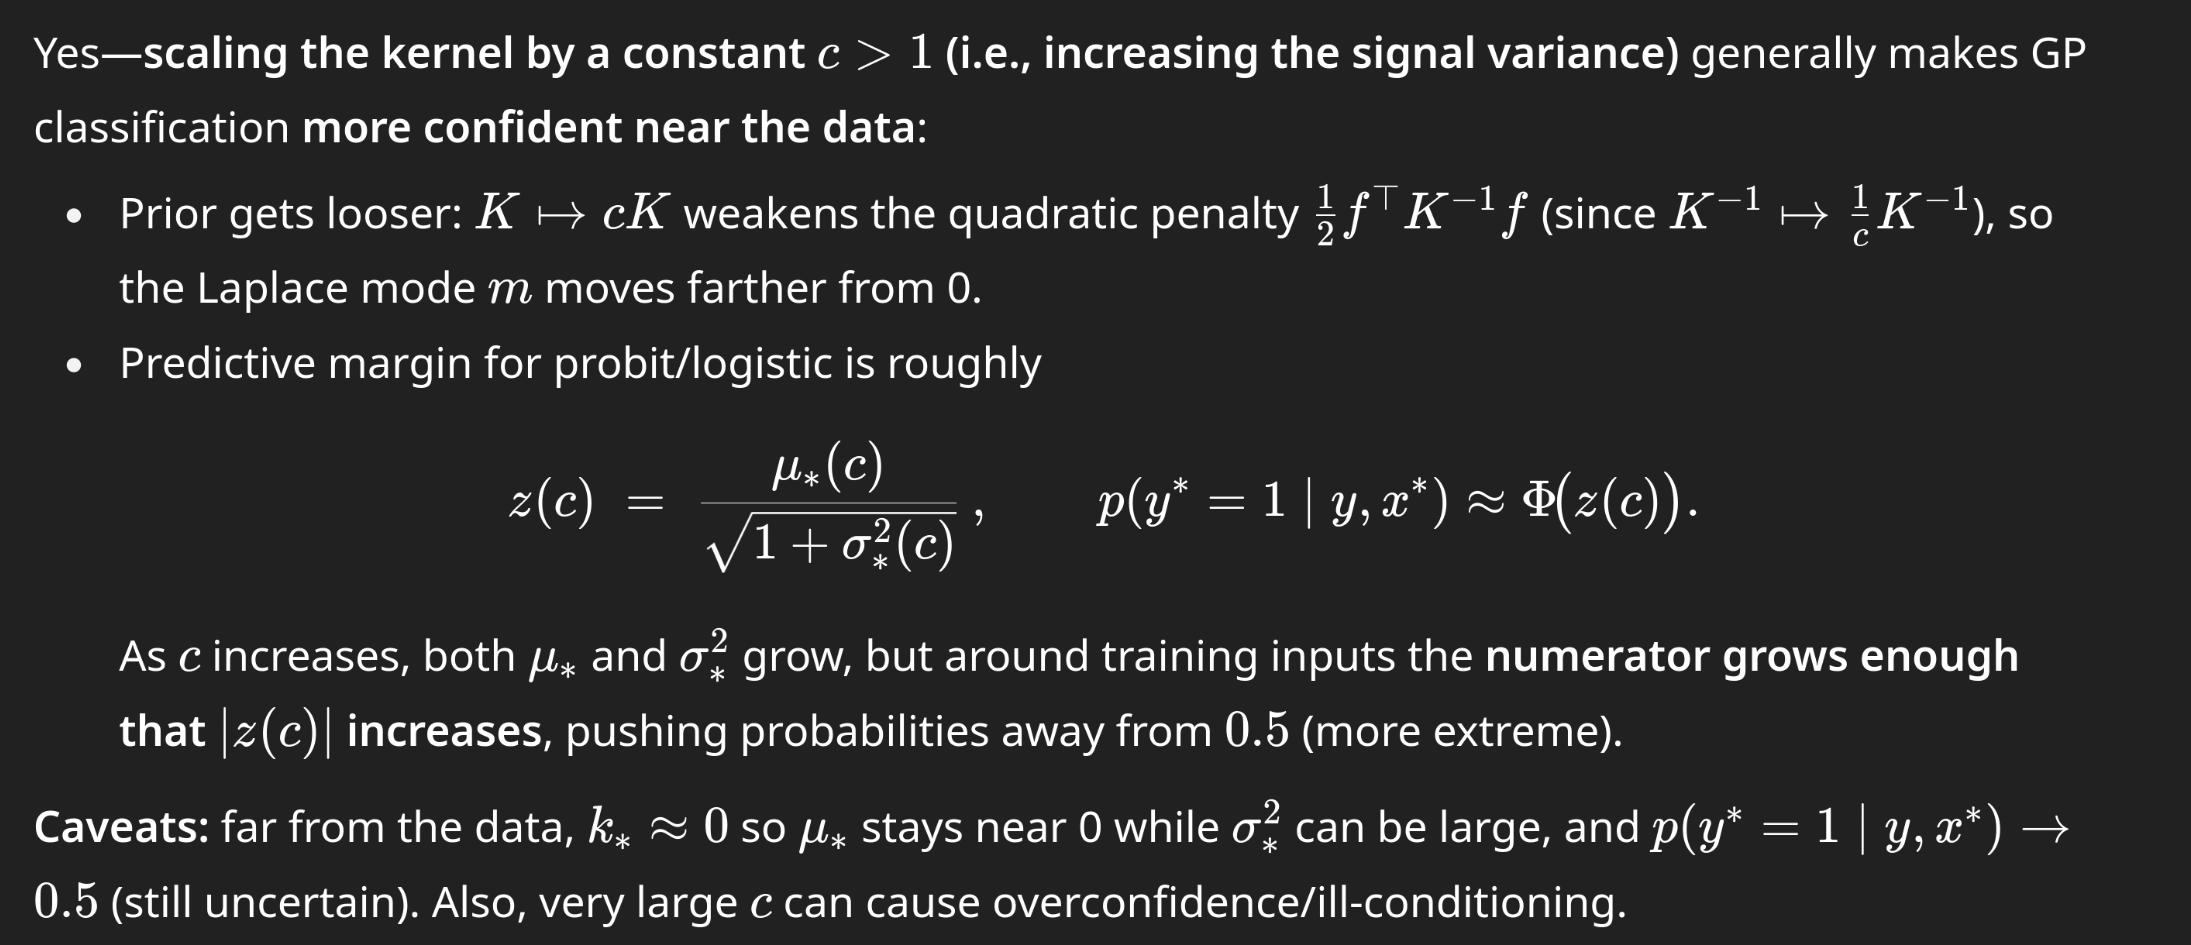

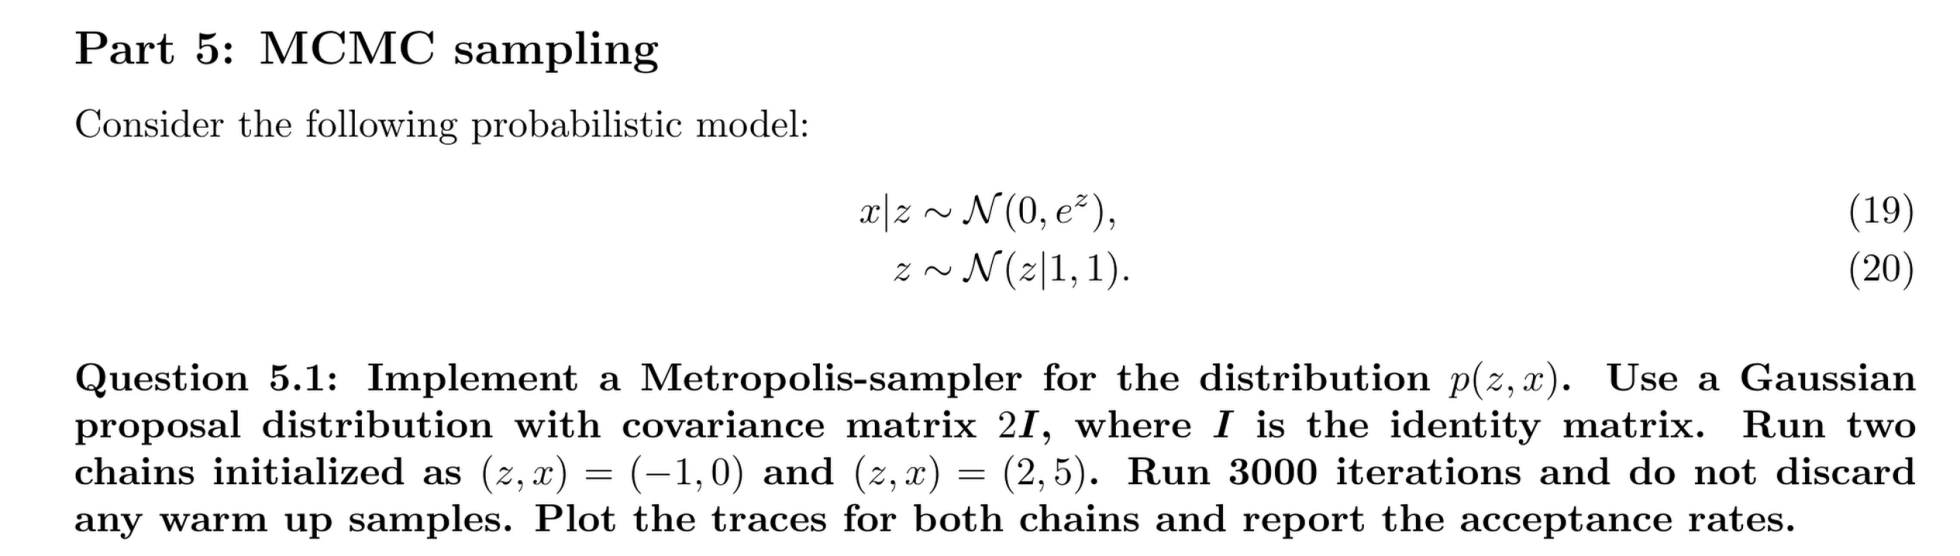

In [266]:
def joint(theta):
    z = theta[0]
    x = theta[1]
    prior = log_npdf(z, 1, 1)
    likelihood = log_npdf(x, 0, jnp.exp(z))
    
    return prior + likelihood

In [279]:
theta1 = MH.metropolis(log_target=joint, num_params=2, tau=jnp.sqrt(2), num_iter=30000, theta_init=jnp.array([-1, 0]))

Acceptance ratio: 0.47
30001
(30001, 2)


In [280]:
theta2 = MH.metropolis(log_target=joint, num_params=2, tau=jnp.sqrt(2), num_iter=30000, theta_init=jnp.array([2.0, 5.0]))

Acceptance ratio: 0.47
30001
(30001, 2)


In [282]:
print(theta1[:, 1])

z1 = theta1[:, 0]
x1 = theta1[:, 1]
z2 = theta2[:, 0]
x2 = theta2[:, 1]




[0.         0.         0.98829373 ... 1.18918943 1.18918943 0.80235465]


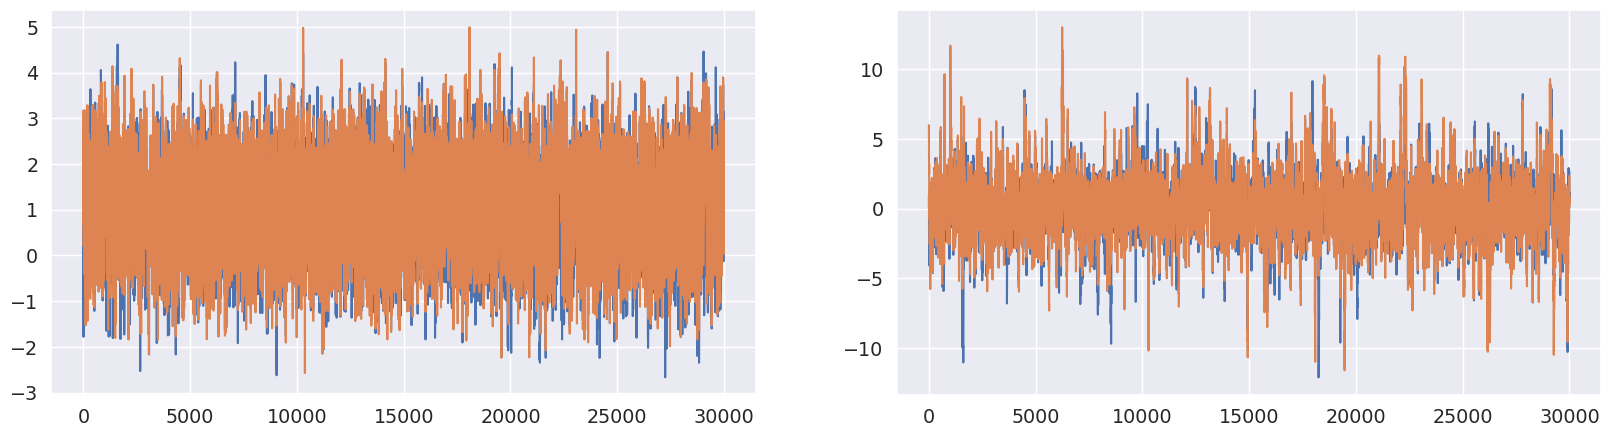

In [283]:
# plot resutls
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
axes[0].plot(z1)
axes[0].plot(z2)

axes[1].plot(x1)
axes[1].plot(x2)


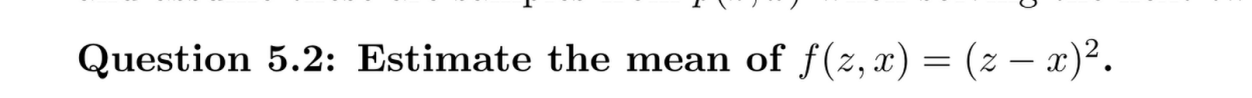
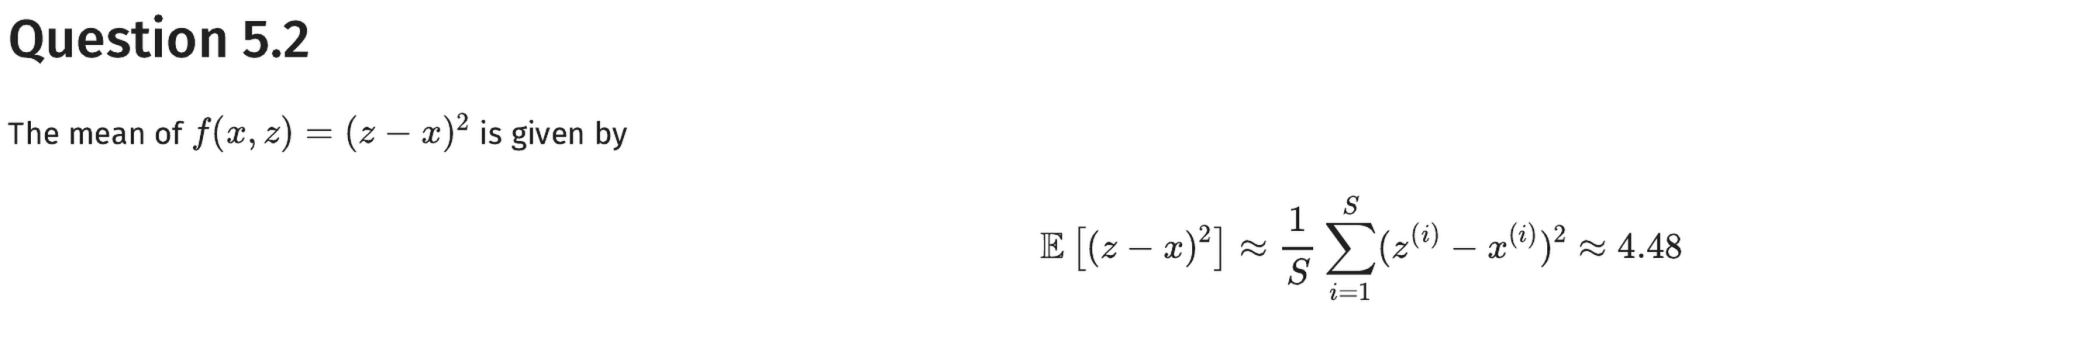

In [284]:
zs = jnp.concatenate([z1, z2])
xs = jnp.concatenate([x1, x2])

In [285]:
f = lambda z, x: (z - x)**2 

print(jnp.mean(f(xs, zs)))

6.891780249612682


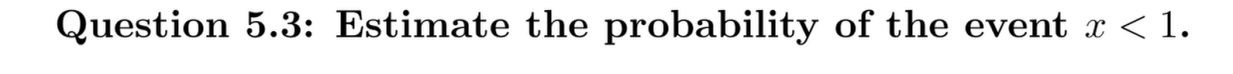

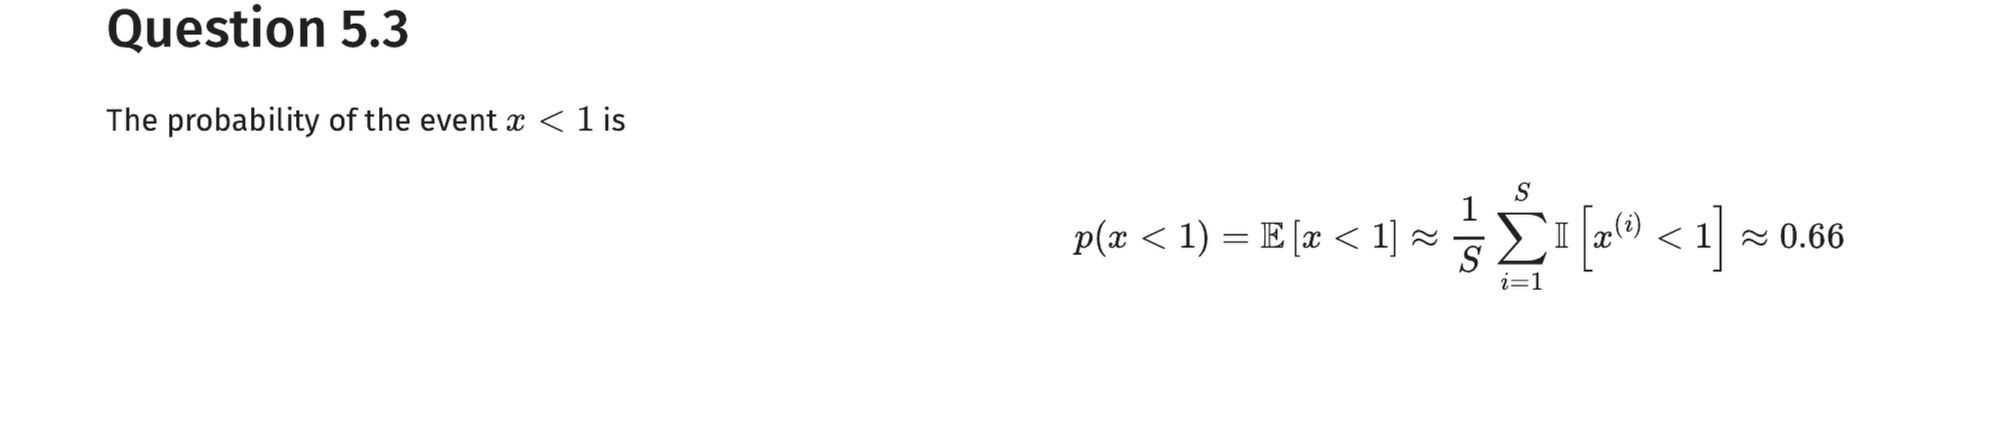

In [286]:
print(jnp.mean(xs < 1))

0.7291756


Acceptance rates — chain 1: 45.63%, chain 2: 46.03%


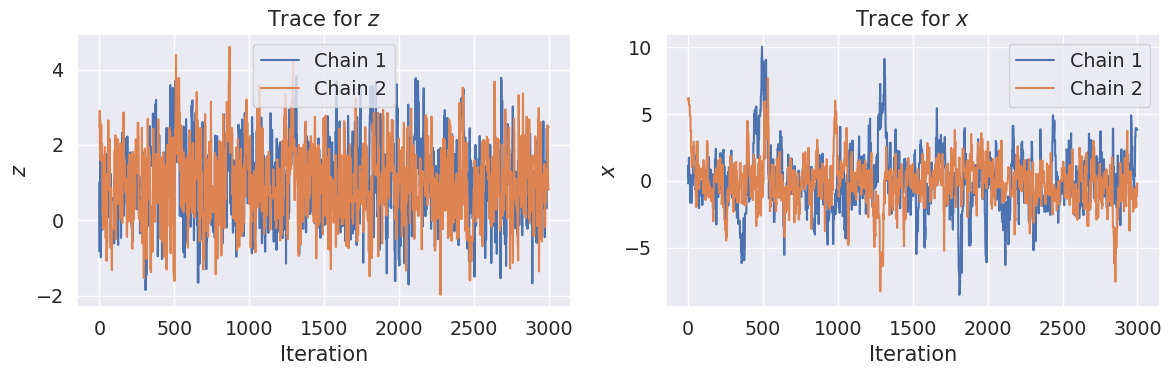

In [277]:
import numpy as np
import matplotlib.pyplot as plt

# --------- densities ----------
def log_npdf(x, m, v):
    """Log N(x | m, v) with variance v (not std)."""
    return -0.5 * (np.log(2 * np.pi * v) + ((x - m) ** 2) / v)

def log_target(theta):
    """
    Joint log-density:
      z ~ N(1, 1)
      x | z ~ N(0, exp(z))
    """
    z, x = theta
    return log_npdf(z, 1.0, 1.0) + log_npdf(x, 0.0, np.exp(z))

# --------- Metropolis (random-walk) ----------
def metropolis(logp, num_params, tau, num_iter, theta_init, rng):
    """
    Random-walk Metropolis with Gaussian proposals:
      theta' = theta + tau * N(0, I)
    """
    theta = np.array(theta_init, dtype=float)
    samples = np.zeros((num_iter, num_params), dtype=float)
    accepted = 0

    curr_lp = logp(theta)
    for t in range(num_iter):
        prop = theta + tau * rng.normal(size=num_params)
        prop_lp = logp(prop)
        if np.log(rng.uniform()) < (prop_lp - curr_lp):
            theta, curr_lp = prop, prop_lp
            accepted += 1
        samples[t] = theta
    acc_rate = accepted / num_iter
    return samples, acc_rate

# --------- run two chains ----------
rng1 = np.random.default_rng(0)
rng2 = np.random.default_rng(1)

samples1, acc1 = metropolis(
    log_target, num_params=2, tau=np.sqrt(2.0), num_iter=3000, theta_init=[-1.0, 0.0], rng=rng1
)
samples2, acc2 = metropolis(
    log_target, num_params=2, tau=np.sqrt(2.0), num_iter=3000, theta_init=[2.0, 5.0], rng=rng2
)

print(f"Acceptance rates — chain 1: {acc1:.2%}, chain 2: {acc2:.2%}")

# --------- trace plots ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(samples1[:, 0], label="Chain 1")
ax[0].plot(samples2[:, 0], label="Chain 2")
ax[0].set(title="Trace for $z$", xlabel="Iteration", ylabel="$z$")
ax[0].legend()

ax[1].plot(samples1[:, 1], label="Chain 1")
ax[1].plot(samples2[:, 1], label="Chain 2")
ax[1].set(title="Trace for $x$", xlabel="Iteration", ylabel="$x$")
ax[1].legend()

plt.tight_layout()
plt.show()


In [278]:
samples = jnp.concatenate([samples1, samples2])
z, x = samples.T 
f = lambda theta: (z - x)**2 
print(jnp.mean(f(samples)))

6.26628451323517
